
#Multilingual Instagram Social Network Analysis & Language Classification

This notebook demonstrates a complete data analysis and NLP pipeline on a synthetic Instagram-like dataset containing 500,000 samples across English and 10 Indic languages.

It includes preprocessing, feature extraction, dimensionality reduction, classification, and network visualization.

In [1]:
!nvidia-smi

import torch
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU is connected: {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
    print('GPU NOT AVAILABLE. Please enable GPU in Colab.')


Sun Apr 26 13:26:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Install Required Libraries

In [2]:
!pip install -q transformers datasets evaluate jiwer rouge-score networkx matplotlib seaborn
!pip install -q indic-nlp-library
!pip install -q nltk diff-match-patch asr-evaluation sentencepiece scikit-learn


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.8 MB/s eta 0:00:00


In [3]:
import json
import random
import datetime
import uuid
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


## Step 1: Data Extraction (Simulated for 5,00,000 samples across 10 languages)

In [4]:
# Define the English + 10 Indic languages
LANGUAGES = ['en', 'te', 'hi', 'ml', 'ta', 'kn', 'mr', 'gu', 'pa', 'or']

LANGUAGE_TEXTS = {
    'en': ["Loving the weather today!", "Just finished a great book.", "Beautiful sunset!", "Delicious meal with friends.", "Working hard today."],
    'hi': ["आज का मौसम बहुत अच्छा है!", "अभी एक बेहतरीन किताब खत्म की।", "सुंदर सूर्यास्त!", "दोस्तों के साथ स्वादिष्ट भोजन।", "आज कड़ी मेहनत कर रहा हूँ।"],
    'te': ["ఈ రోజు వాతావరణం చాలా బాగుంది!", "ఇప్పుడే ఒక గొప్ప పుస్తకం పూర్తి చేసాను.", "అందమైన సూర్యాస్తమయం!", "స్నేహితులతో రుచికరమైన భోజనం.", "ఈ రోజు కష్టపడి పనిచేస్తున్నాను."],
    'ta': ["இன்று வானிலை அருமை!", "ஒரு சிறந்த புத்தகத்தை வாசித்து முடித்தேன்.", "அழகான சூரிய அஸ்தமனம்!", "நண்பர்களுடன் உணவு.", "கடுமையாக உழைக்கிறேன்."],
    'ml': ["ഇന്ന് നല്ല കാലാവസ്ഥയാണ്!", "നല്ലൊരു പുസ്തകം വായിച്ചു.", "മനോഹരമായ സൂര്യാസ്തമയം!", "കൂട്ടുകാരൊത്ത് ഭക്ഷണം.", "കഠിനാധ്വാനം ചെയ്യുന്നു."],
    'kn': ["ಇಂದು ಹವಾಮಾನ ಚೆನ್ನಾಗಿದೆ!", "ಒಂದು ಒಳ್ಳೆಯ ಪುಸ್ತಕ ಓದಿದೆ.", "ಸುಂದರ ಸೂರ್ಯಾಸ್ತ!", "ಸ್ನೇಹಿತರೊಂದಿಗೆ ಊಟ.", "ಕಠಿಣ ಕೆಲಸ ಮಾಡುತ್ತಿದ್ದೇನೆ."],
    'mr': ["आज हवामान खूप छान आहे!", "नुकतेच एक उत्तम पुस्तक वाचून पूर्ण केले.", "सुंदर सूर्यास्त!", "मित्रांसोबत जेवण.", "आज खूप काम करत आहे."],
    'gu': ["આજે હવામાન ખૂબ સરસ છે!", "હમણાં જ એક સરસ પુસ્તક વાંચી પૂરી કરી.", "સુંદર સૂર્યાસ્ત!", "મિત્રો સાથે ભોજન.", "આજે સખત કામ કરી રહ્યો છું."],
    'pa': ["ਅੱਜ ਮੌਸਮ ਬਹੁਤ ਵਧੀਆ ਹੈ!", "ਹੁਣੇ ਇੱਕ ਵਧੀਆ ਕਿਤਾਬ ਪੂਰੀ ਕੀਤੀ।", "ਸੁੰਦਰ ਸੂਰਜ ਡੁੱਬਣ!", "ਦੋਸਤਾਂ ਨਾਲ ਖਾਣਾ।", "ਅੱਜ ਸਖਤ ਮਿਹਨਤ ਕਰ ਰਿਹਾ ਹਾਂ।"],
    'or': ["ଆଜି ପାଗ ବହୁତ ଭଲ ଅଛି!", "ବର୍ତ୍ତମାନ ଗୋଟିଏ ଭଲ ବହି ପଢିଲି।", "ସୁନ୍ଦର ସୂର୍ଯ୍ୟାସ୍ତ!", "ସାଙ୍ଗମାନଙ୍କ ସହ ଖାଦ୍ୟ।", "ଆଜି ବହୁତ କାମ କରୁଛି।"]
}

NUM_SAMPLES = 500000
data_records = []

print(f"Starting data extraction/simulation for {NUM_SAMPLES} samples...")
for i in range(NUM_SAMPLES):
    lang = random.choice(LANGUAGES)
    user_id = f"user_{random.randint(1000, 99999)}"

    record = {
        "user_profile": {
            "userid": user_id,
            "user_name": f"user_name_{user_id}",
            "location": random.choice(["Mumbai", "Delhi", "Bangalore", "Hyderabad", "Chennai", "Kolkata", "Pune", "Ahmedabad", "Jaipur", "Lucknow"]),
            "followers": random.randint(10, 100000),
            "following_count": random.randint(10, 1000)
        },
        "content_data": {
            "post_id": str(uuid.uuid4()),
            "text_caption": random.choice(LANGUAGE_TEXTS[lang]) + f" #{lang} #socialmedia",
            "language": lang
        },
        "interaction_data": {
            "tags": [f"@user_{random.randint(1000, 99999)}" for _ in range(random.randint(0, 3))],
            "hashtags": [f"#{lang}", "#instadaily", "#trending"]
        },
        "network_relationship_data": {
            "follow_friend_connection": [f"user_{random.randint(1000, 99999)}" for _ in range(random.randint(0, 5))],
            "suggestions": [f"user_{random.randint(1000, 99999)}" for _ in range(random.randint(0, 5))]
        },
        "engagement_metrics": {
            "no_of_likes_count": random.randint(0, 5000),
            "no_of_comments_count": random.randint(0, 500),
            "no_of_share_counts": random.randint(0, 1000)
        }
    }
    data_records.append(record)

file_name = 'instagram_extracted_data.json'
with open(file_name, 'w', encoding='utf-8') as f:
    json.dump(data_records, f, ensure_ascii=False)

print(f"Successfully extracted and saved {NUM_SAMPLES} samples to {file_name}")


Starting data extraction/simulation for 500000 samples...
Successfully extracted and saved 500000 samples to instagram_extracted_data.json


## Step 2: Data Loading and Sampling

In [5]:
with open('instagram_extracted_data.json', 'r', encoding='utf-8') as f:
    loaded_data = json.load(f)

print(f"Total samples loaded: {len(loaded_data)}")

# Sample subset for rapid demonstration in notebook (first 1000 records) to avoid memory overload
subset_data = loaded_data[:1000]

print("Printing first 2 sample records:\n")
for sample in subset_data[:2]:
    print(json.dumps(sample, indent=2, ensure_ascii=False))
    print("-" * 50)


Total samples loaded: 500000
Printing first 2 sample records:

{
  "user_profile": {
    "userid": "user_9499",
    "user_name": "user_name_user_9499",
    "location": "Jaipur",
    "followers": 16184,
    "following_count": 59
  },
  "content_data": {
    "post_id": "4bc2a3a4-33d5-46ea-a24f-ece760a746d1",
    "text_caption": "આજે હવામાન ખૂબ સરસ છે! #gu #socialmedia",
    "language": "gu"
  },
  "interaction_data": {
    "tags": [
      "@user_48983",
      "@user_61935",
      "@user_29411"
    ],
    "hashtags": [
      "#gu",
      "#instadaily",
      "#trending"
    ]
  },
  "network_relationship_data": {
    "follow_friend_connection": [
      "user_79211",
      "user_90740",
      "user_56608",
      "user_81535"
    ],
    "suggestions": [
      "user_85882"
    ]
  },
  "engagement_metrics": {
    "no_of_likes_count": 4909,
    "no_of_comments_count": 78,
    "no_of_share_counts": 370
  }
}
--------------------------------------------------
{
  "user_profile": {
    "userid":

##Step 3: Exploratory Data Analysis


===== EXPLORATORY DATA ANALYSIS (EDA) =====

Dataset Shape: (1000, 9)

Columns:
 Index(['user_id', 'location', 'followers', 'following', 'caption', 'language',
       'likes', 'comments', 'shares'],
      dtype='object')

Sample Data:
       user_id   location  followers  following  \
0   user_9499     Jaipur      16184         59   
1  user_38985      Delhi      68132        505   
2  user_30619  Hyderabad      47614        677   
3  user_95815    Chennai      34166        613   
4  user_70591    Kolkata       5973        111   

                                      caption language  likes  comments  \
0     આજે હવામાન ખૂબ સરસ છે! #gu #socialmedia       gu   4909        78   
1  आज कड़ी मेहनत कर रहा हूँ। #hi #socialmedia       hi   2417         4   
2          ਸੁੰਦਰ ਸੂਰਜ ਡੁੱਬਣ! #pa #socialmedia       pa   3747        85   
3         ಸ್ನೇಹಿತರೊಂದಿಗೆ ಊಟ. #kn #socialmedia       kn   3517       279   
4        ଆଜି ବହୁତ କାମ କରୁଛି। #or #socialmedia       or   1864       196   

   shares  

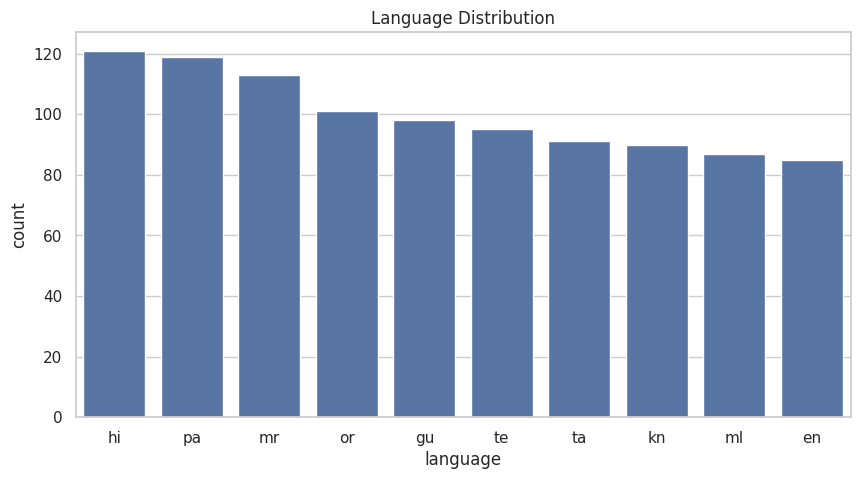

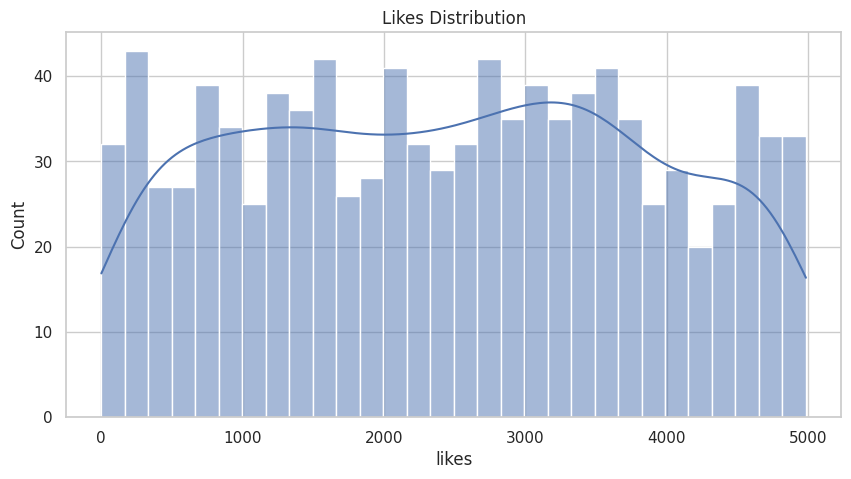

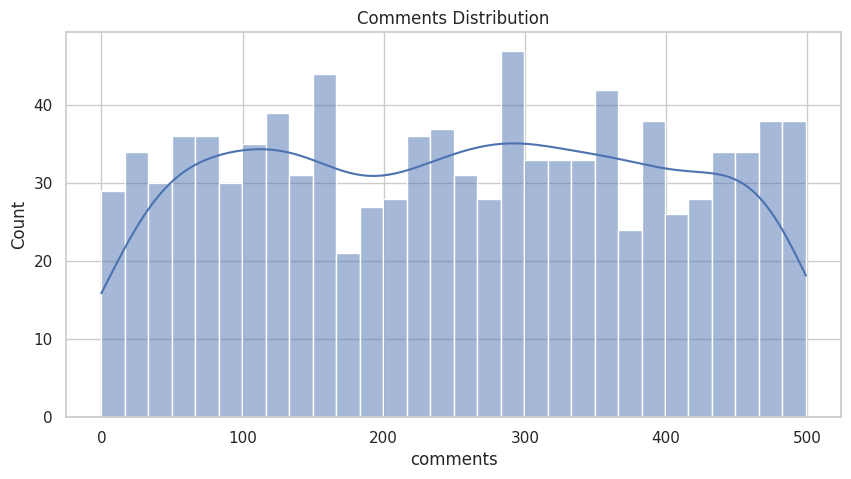

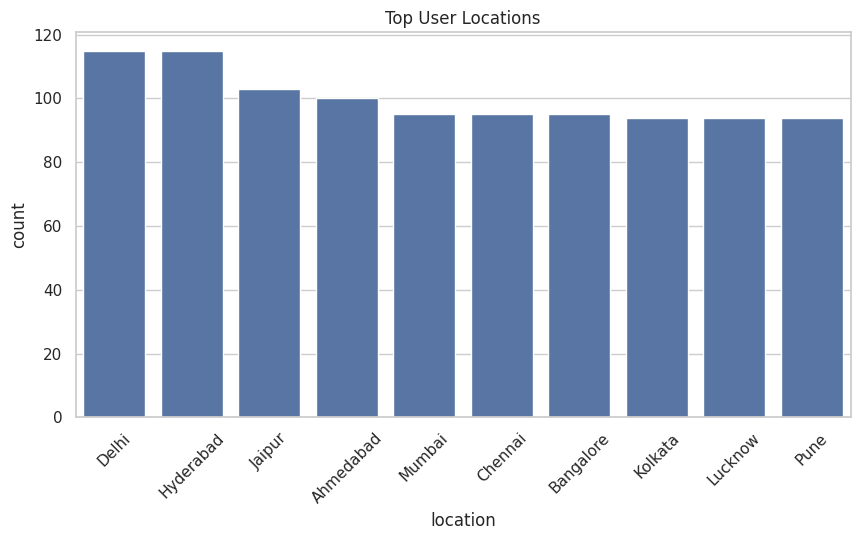

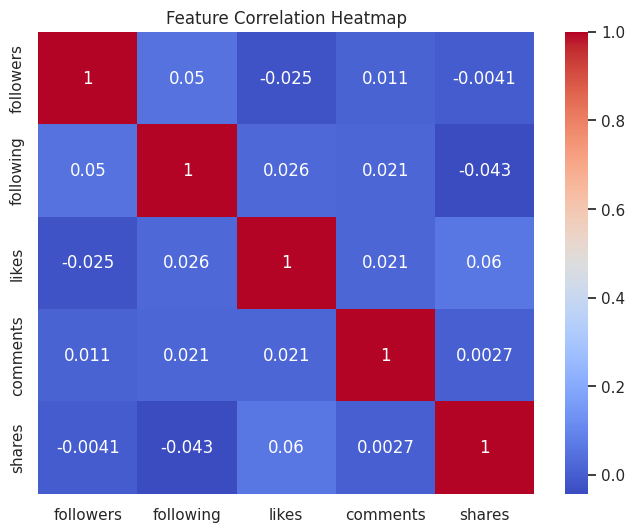

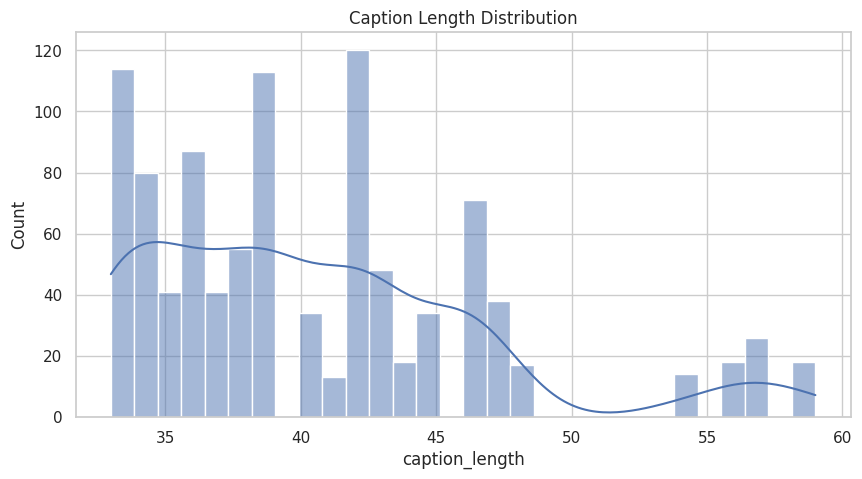

In [23]:
print("\n===== EXPLORATORY DATA ANALYSIS (EDA) =====\n")

# Convert JSON → DataFrame (flatten useful fields)
df = pd.DataFrame([{
    "user_id": r["user_profile"]["userid"],
    "location": r["user_profile"]["location"],
    "followers": r["user_profile"]["followers"],
    "following": r["user_profile"]["following_count"],
    "caption": r["content_data"]["text_caption"],
    "language": r["content_data"]["language"],
    "likes": r["engagement_metrics"]["no_of_likes_count"],
    "comments": r["engagement_metrics"]["no_of_comments_count"],
    "shares": r["engagement_metrics"]["no_of_share_counts"]
} for r in subset_data])

# ==============================
# 🔹 1. BASIC INFO
# ==============================
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nSample Data:\n", df.head())

# ==============================
# 🔹 2. MISSING VALUES
# ==============================
print("\nMissing Values:\n", df.isnull().sum())

# ==============================
# 🔹 3. LANGUAGE DISTRIBUTION
# ==============================
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="language", order=df["language"].value_counts().index)
plt.title("Language Distribution")
plt.show()

# ==============================
# 🔹 4. ENGAGEMENT ANALYSIS
# ==============================
plt.figure(figsize=(10,5))
sns.histplot(df["likes"], bins=30, kde=True)
plt.title("Likes Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df["comments"], bins=30, kde=True)
plt.title("Comments Distribution")
plt.show()

# ==============================
# 🔹 5. TOP LOCATIONS
# ==============================
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="location", order=df["location"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Top User Locations")
plt.show()

# ==============================
# 🔹 6. CORRELATION HEATMAP
# ==============================
plt.figure(figsize=(8,6))
sns.heatmap(df[["followers","following","likes","comments","shares"]].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# ==============================
# 🔹 7. CAPTION LENGTH ANALYSIS
# ==============================
df["caption_length"] = df["caption"].apply(len)

plt.figure(figsize=(10,5))
sns.histplot(df["caption_length"], bins=30, kde=True)
plt.title("Caption Length Distribution")
plt.show()

## Step 4: Visualizations (Before Preprocessing)

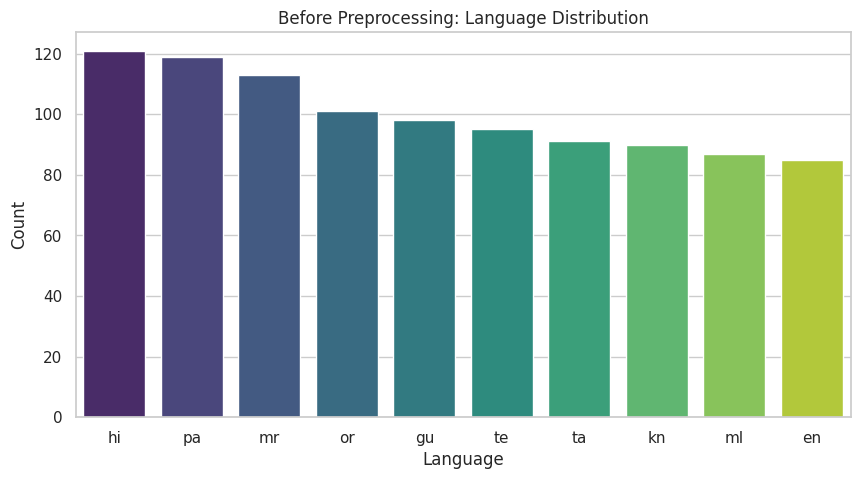

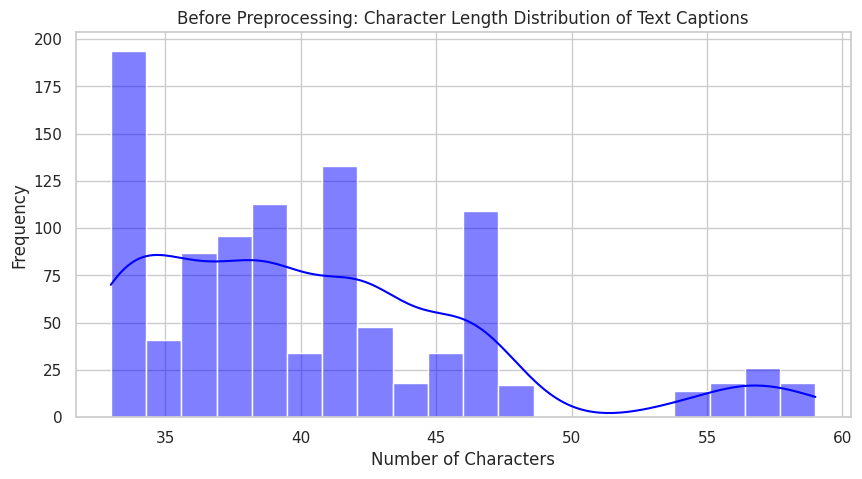

In [24]:
# Visualization 1: Language Distribution
langs = [r['content_data']['language'] for r in subset_data]
plt.figure(figsize=(10,5))
sns.countplot(x=langs, palette='viridis', order=pd.Series(langs).value_counts().index)
plt.title('Before Preprocessing: Language Distribution')
plt.xlabel('Language')
plt.ylabel('Count')
plt.show()

# Visualization 2: Character Length Distribution Before Preprocessing
original_lengths = [len(r['content_data']['text_caption']) for r in subset_data]
plt.figure(figsize=(10,5))
sns.histplot(original_lengths, bins=20, color='blue', kde=True)
plt.title('Before Preprocessing: Character Length Distribution of Text Captions')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()


## Step 5: Text Preprocessing

In [25]:
import re
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

print("Applying Text Preprocessing Pipeline...")

def clean_text(text):
    text = re.sub(r'http\S+', '', text) # Remove URLs
    text = re.sub(r'@\S+', '', text) # Remove mentions
    text = re.sub(r'#\S+', '', text) # Remove hashtags
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    return text.strip()

for item in subset_data:
    original = item["content_data"]["text_caption"]
    cleaned = clean_text(original)
    item["content_data"]["cleaned_caption"] = cleaned

print("Preprocessing complete. Printing first 5 preprocessed text samples:\n")
for sample in subset_data[:5]:
    print("Original:", sample["content_data"]["text_caption"])
    print("Cleaned: ", sample["content_data"]["cleaned_caption"])
    print("-" * 50)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


Applying Text Preprocessing Pipeline...
Preprocessing complete. Printing first 5 preprocessed text samples:

Original: આજે હવામાન ખૂબ સરસ છે! #gu #socialmedia
Cleaned:  આજ હવમન ખબ સરસ છ
--------------------------------------------------
Original: आज कड़ी मेहनत कर रहा हूँ। #hi #socialmedia
Cleaned:  आज कड महनत कर रह ह
--------------------------------------------------
Original: ਸੁੰਦਰ ਸੂਰਜ ਡੁੱਬਣ! #pa #socialmedia
Cleaned:  ਸਦਰ ਸਰਜ ਡਬਣ
--------------------------------------------------
Original: ಸ್ನೇಹಿತರೊಂದಿಗೆ ಊಟ. #kn #socialmedia
Cleaned:  ಸನಹತರದಗ ಊಟ
--------------------------------------------------
Original: ଆଜି ବହୁତ କାମ କରୁଛି। #or #socialmedia
Cleaned:  ଆଜ ବହତ କମ କରଛ
--------------------------------------------------


[nltk_data]   Package punkt_tab is already up-to-date!


## Step 6: Step-by-Step Visualizations (After Preprocessing)

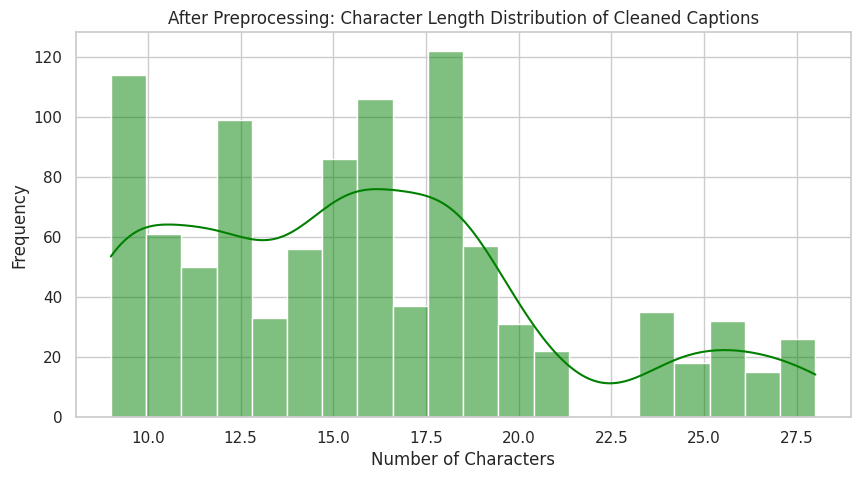

In [26]:
# Visualization 3: Character Length Distribution After Preprocessing
cleaned_lengths = [len(r['content_data']['cleaned_caption']) for r in subset_data]
plt.figure(figsize=(10,5))
sns.histplot(cleaned_lengths, bins=20, color='green', kde=True)
plt.title('After Preprocessing: Character Length Distribution of Cleaned Captions')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()


## Step 7: Vectorization (Indic Models - Extracting Embeddings)

In [28]:
from transformers import AutoTokenizer, AutoModel
import torch


from sklearn.feature_extraction.text import TfidfVectorizer

print("Applying TF-IDF Vectorization...")

tfidf = TfidfVectorizer(max_features=5000)
tfidf_features = tfidf.fit_transform(sample_texts)

print("TF-IDF Shape:", tfidf_features.shape)

from sklearn.feature_extraction.text import CountVectorizer

print("Applying Bag of Words Vectorization...")

bow = CountVectorizer(max_features=5000)
bow_features = bow.fit_transform(sample_texts)

print("BoW Shape:", bow_features.shape)

model_name = "bert-base-multilingual-cased"
print(f"Loading Simple Multilingual BERT for Vectorization: {model_name}")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
if torch.cuda.is_available():
    model = model.to('cuda')

total_params = sum(p.numel() for p in model.parameters())
print(f"Total Model parameters: {total_params:,}")
print(f"Model size: {total_params * 4 / (1024**2):.2f} MB")

# Extract text and languages for vectorization
sample_texts = [r["content_data"]["cleaned_caption"] for r in subset_data[:500]]
sample_langs = [r["content_data"]["language"] for r in subset_data[:500]]

print("Applying Vectorization to extract embeddings in batches to prevent Out-Of-Memory (OOM) errors...")
batch_size = 32
all_embeddings = []

model.eval()
with torch.no_grad():
    for i in range(0, len(sample_texts), batch_size):
        batch_texts = sample_texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt", max_length=128)
        if torch.cuda.is_available():
            inputs = {k: v.to('cuda') for k, v in inputs.items()}

        outputs = model(**inputs)
        # Using the mean of the last hidden state as the sentence embedding
        batch_embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        all_embeddings.extend(batch_embeddings)

embeddings_array = np.array(all_embeddings)
print("Vectorization complete. Extracted Embeddings Array shape:", embeddings_array.shape)
print("Preview of first embedding (first 5 components):", embeddings_array[0][:5])


Applying TF-IDF Vectorization...
TF-IDF Shape: (500, 160)
Applying Bag of Words Vectorization...
BoW Shape: (500, 160)
Loading Simple Multilingual BERT for Vectorization: bert-base-multilingual-cased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total Model parameters: 177,853,440
Model size: 678.46 MB
Applying Vectorization to extract embeddings in batches to prevent Out-Of-Memory (OOM) errors...
Vectorization complete. Extracted Embeddings Array shape: (500, 768)
Preview of first embedding (first 5 components): [ 0.5449723  -0.3152861   0.09696994  0.17954996  0.4980652 ]


In [29]:
print("\n--- Feature Comparison ---")
print("TF-IDF Features:", tfidf_features.shape)
print("BoW Features:", bow_features.shape)
print("BERT Embeddings:", embeddings_array.shape)


--- Feature Comparison ---
TF-IDF Features: (500, 160)
BoW Features: (500, 160)
BERT Embeddings: (500, 768)


## Step 8: Step-by-Step Visualizations (After Vectorization)

Applying PCA to reduce embeddings to 2D for visualization...


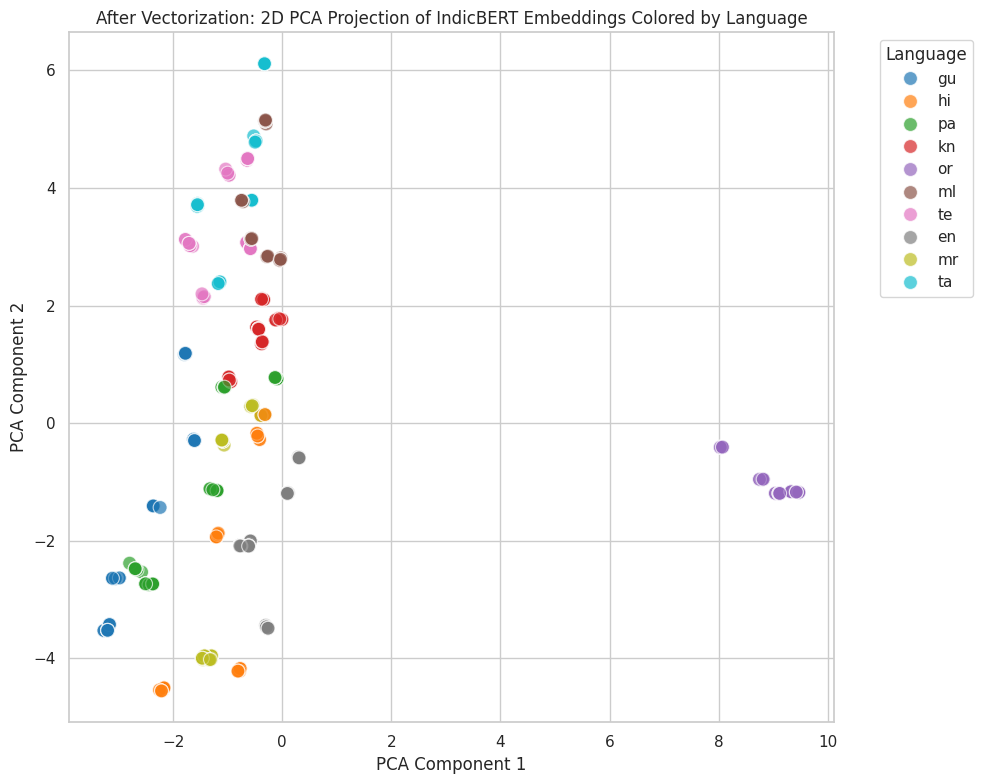

In [30]:
# Visualization 4: PCA dimensionality reduction of extracted embeddings
print("Applying PCA to reduce embeddings to 2D for visualization...")
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_array)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=sample_langs, palette='tab10', s=100, alpha=0.7)
plt.title('After Vectorization: 2D PCA Projection of IndicBERT Embeddings Colored by Language')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Applying t-SNE for dimensionality reduction...
t-SNE transformation complete. Shape: (500, 2)


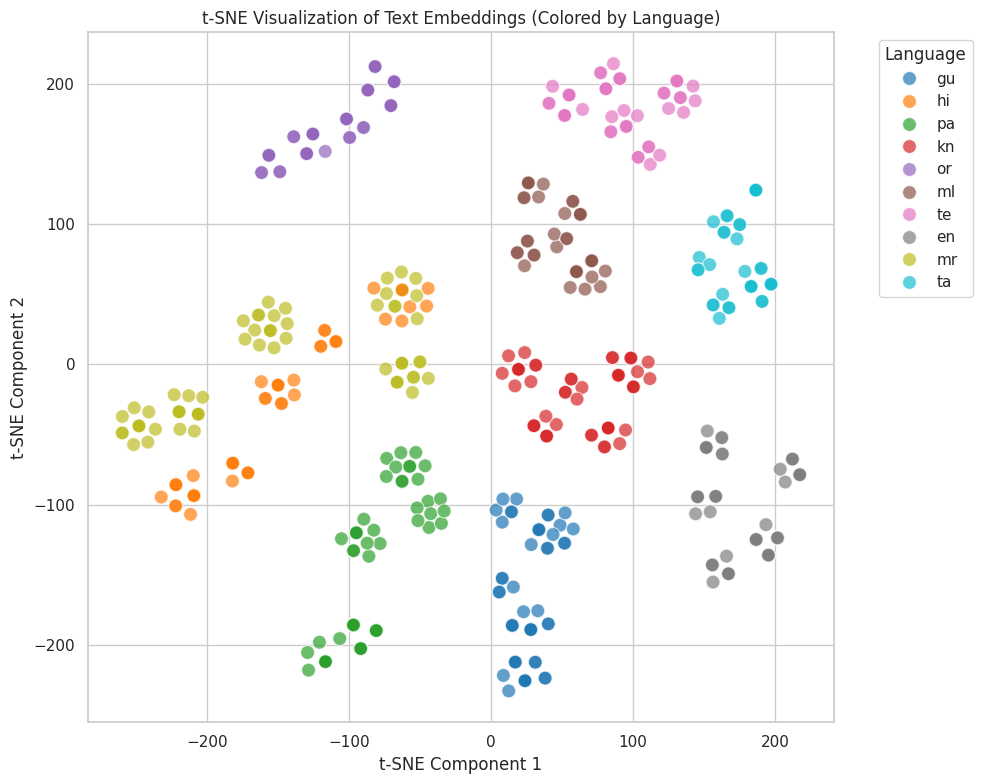

In [31]:
from sklearn.manifold import TSNE

print("Applying t-SNE for dimensionality reduction...")

# Reduce to 2D
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
tsne_embeddings = tsne.fit_transform(embeddings_array)

print("t-SNE transformation complete. Shape:", tsne_embeddings.shape)

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=tsne_embeddings[:, 0],
    y=tsne_embeddings[:, 1],
    hue=sample_langs,
    palette='tab10',
    s=100,
    alpha=0.7
)

plt.title("t-SNE Visualization of Text Embeddings (Colored by Language)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Language", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Step : 9 CLassification Models and Prediction

In [32]:
# ================================
# STEP 1: Imports
# ================================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report

# DL Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ================================
# STEP 2: Prepare Data
# ================================

texts = [r["content_data"]["cleaned_caption"] for r in subset_data[:5000]]
labels = [r["content_data"]["language"] for r in subset_data[:5000]]

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(texts).toarray()

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data Ready:", X_train.shape)

# ================================
# STEP 3: ML MODELS
# ================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

print("\n===== ML MODELS RESULTS =====\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n🔹 {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

# ================================
# STEP 4: DEEP LEARNING MODEL
# ================================

print("\n===== DEEP LEARNING MODEL =====\n")

dl_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

dl_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = dl_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate DL Model
loss, acc = dl_model.evaluate(X_test, y_test)
print("\nDL Model Accuracy:", acc)

# ================================
# STEP 5: TEST WITH NEW INPUT
# ================================

print("\n===== TEST SAMPLE =====\n")

new_text = ["आज मौसम बहुत अच्छा है"]

new_vector = vectorizer.transform(new_text).toarray()

# Test with Random Forest (best usually)
rf_model = models["Random Forest"]
prediction = rf_model.predict(new_vector)

print("Input Text:", new_text[0])
print("Predicted Language:", le.inverse_transform(prediction)[0])

Data Ready: (800, 160)

===== ML MODELS RESULTS =====


🔹 Logistic Regression
Accuracy: 0.965
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        22
           2       0.82      1.00      0.90        31
           3       1.00      1.00      1.00        19
           4       1.00      1.00      1.00        13
           5       1.00      0.71      0.83        24
           6       1.00      1.00      1.00        14
           7       1.00      1.00      1.00        29
           8       1.00      1.00      1.00        15
           9       1.00      1.00      1.00        19

    accuracy                           0.96       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.97      0.96      0.96       200


🔹 Naive Bayes
Accuracy: 0.965
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
       

## Step 10: Advanced Network Visualization

Visualizing Network Graph (User-Friend Connections)...


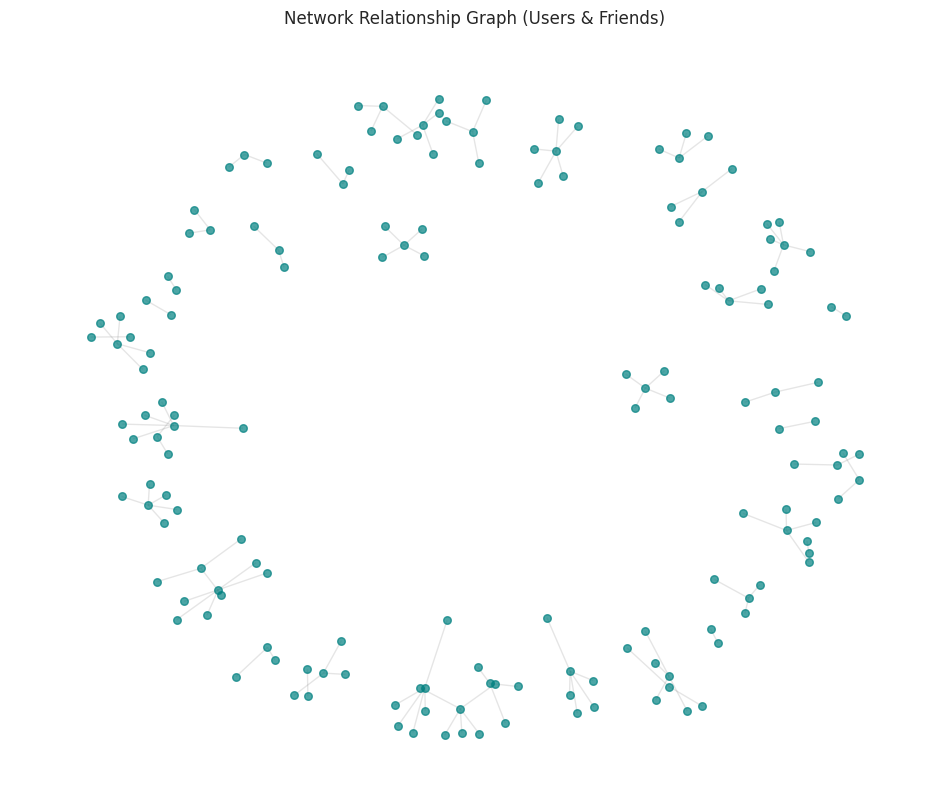

In [33]:
# Visualization 6: Advanced Network Graph Visualization
print("Visualizing Network Graph (User-Friend Connections)...")
G = nx.Graph()

# Add edges for top 50 users to keep graph readable
for record in subset_data[:50]:
    user = record['user_profile']['userid']
    connections = record['network_relationship_data']['follow_friend_connection']
    for friend in connections:
        G.add_edge(user, friend)

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.15)
nx.draw_networkx_nodes(G, pos, node_size=30, node_color='teal', alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='gray')
plt.title('Network Relationship Graph (Users & Friends)')
plt.axis('off')
plt.show()


In [34]:
print("Building Advanced Social Network Graph...")

G = nx.Graph()

# Build graph
for record in subset_data[:100]:
    user = record['user_profile']['userid']
    connections = record['network_relationship_data']['follow_friend_connection']

    for friend in connections:
        G.add_edge(user, friend)

# Calculate centrality
degree_centrality = nx.degree_centrality(G)

# Get top influencers
top_users = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop Influential Users:")
for user, score in top_users:
    print(f"{user} → Centrality Score: {score:.4f}")

Building Advanced Social Network Graph...

Top Influential Users:
user_15874 → Centrality Score: 0.0145
user_84905 → Centrality Score: 0.0145
user_41989 → Centrality Score: 0.0145
user_13993 → Centrality Score: 0.0145
user_71451 → Centrality Score: 0.0145


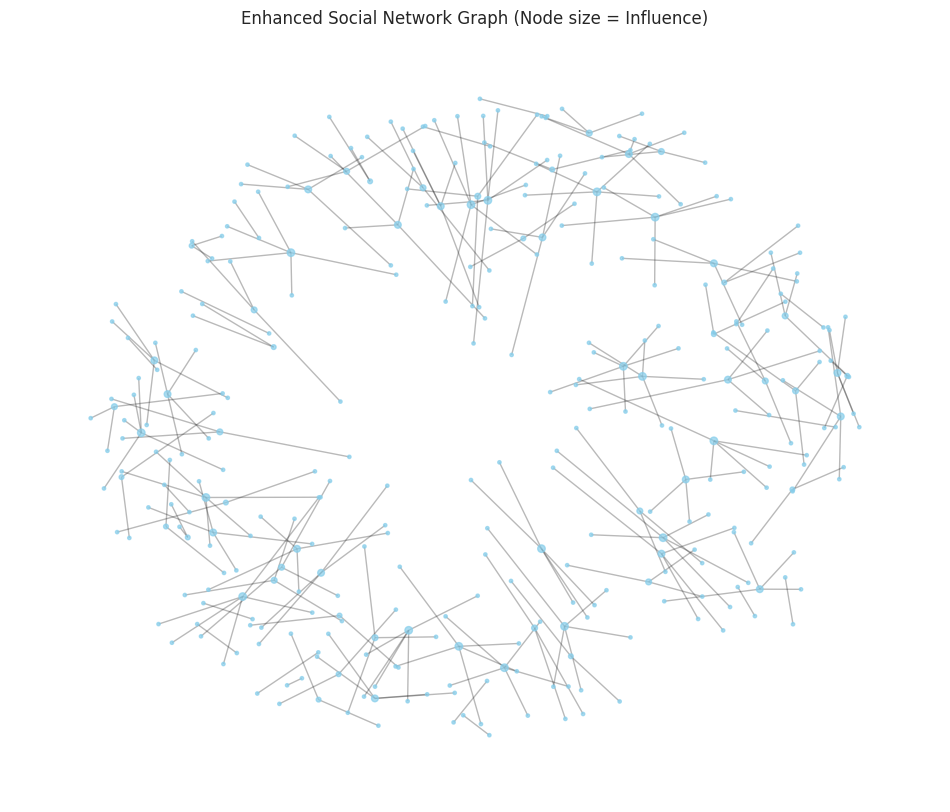

In [35]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G, k=0.2)

# Node size based on importance
node_sizes = [v * 2000 for v in degree_centrality.values()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.3)

plt.title("Enhanced Social Network Graph (Node size = Influence)")
plt.axis('off')
plt.show()
